In [4]:
!pip install numpy
!pip install pandas
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 22.6 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 35.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 26.9 MB/s eta 0:00:00


In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [100]:
def load_csv_files(start_year=2004, end_year=2004):
    """
    Loads the indication-reaction, indication-drug, and drug-reaction association CSV files into Pandas DataFrames.

    Parameters:
        start_year (int): The start year of the dataset.
        end_year (int): The end year of the dataset.

    Returns:
        tuple: (ind_rea_df, ind_drug_df, drug_rea_df)
    """
    # Define directory path
    results_dir = f'../results/{start_year}-{end_year}'

    # Define file paths
    ind_rea_file = os.path.join(results_dir, "indication_reaction_associations.csv")
    ind_drug_file = os.path.join(results_dir, "indication_drug_associations.csv")
    drug_rea_file = os.path.join(results_dir, "drug_reaction_associations.csv")

    # Load CSVs into DataFrames
    try:
        ind_rea_df = pd.read_csv(ind_rea_file)
        print(f"Loaded {len(ind_rea_df)} rows from {ind_rea_file}")
    except Exception as e:
        print(f"Error loading {ind_rea_file}: {e}")
        ind_rea_df = None

    try:
        ind_drug_df = pd.read_csv(ind_drug_file)
        print(f"Loaded {len(ind_drug_df)} rows from {ind_drug_file}")
    except Exception as e:
        print(f"Error loading {ind_drug_file}: {e}")
        ind_drug_df = None

    try:
        drug_rea_df = pd.read_csv(drug_rea_file)
        print(f"Loaded {len(drug_rea_df)} rows from {drug_rea_file}")
    except Exception as e:
        print(f"Error loading {drug_rea_file}: {e}")
        drug_rea_df = None

    return ind_rea_df, ind_drug_df, drug_rea_df

In [106]:
def confounder_drug_reaction_correlation(
    ind_rea_df, ind_drug_df, drug_rea_df, 
    conf_rea_threshold=100, min_threshold_for_drug=40, num_bins=30, type='proportion',
    conf_rea_col = 'PRR', conf_drug_col = 'PHI', drug_rea_col = 'PRR',
    conf_name='Indication', title=None
):
    """
    Plots:
    - X-axis: Average PHI (conf_drug_col) in equally sized bins of drugs.
    - Y-axis: Mean (or Proportion of drugs in each bin with statistic (drug_rea_col) > min_threshold_for_drug) for the indication's reactions.

    Parameters:
        ind_rea_df (pd.DataFrame): DataFrame with confounder-reaction associations. Initially implemented with indications, but can be other things.
        ind_drug_df (pd.DataFrame): DataFrame with confounder-drug associations. Initiatlly implemented with indications, but can be other things. 
        drug_rea_df (pd.DataFrame): DataFrame with drug-reaction associations.
        ind_rea_threshold (float): Threshold for identifying strong confounder-reaction links. Note used if type == 'mean'
        min_threshold_for_drug (float): PRR threshold for drugs.
        num_bins (int): Number of bins to group drugs based on PHI.
        type (str): 'proportion' or 'mean' to indicate to plot proportion above threshold or mean.
        conf_col (str): Which reaction association statistic to use in the confounder matrix. 
        drug_col (str): which reaction association statistic to use in the drug matrix.
        title (str): override the title

    Returns:
        data (pd.DataFrame): DataFrame with possibly confounded drug-reaction associations.
    """
    
    indication_reactions = ind_rea_df[ind_rea_df[conf_rea_col]>conf_rea_threshold]
    
    data = None
    for ind in indication_reactions["indication"].unique():
        relevant_reactions = list(set(indication_reactions[indication_reactions["indication"] == ind]["reaction"]))
        id = ind_drug_df[ind_drug_df['indication']==ind]
        dr = drug_rea_df[drug_rea_df['reaction'].isin(relevant_reactions)]
        re = id.merge(dr, on="drug", suffixes=['_ind_drug', '_drug_rea'])[['indication', 'reaction', 'drug', f'{conf_drug_col}_ind_drug', f'{drug_rea_col}_drug_rea']]
        if data is None:
            data = re
        else:
            data = pd.concat([data, re], ignore_index=True)

    sorted_data = data.sort_values(by=f'{conf_drug_col}_ind_drug')

    plot_data = list()
    for b, df in enumerate(np.array_split(sorted_data, num_bins)):
        yprop = (df[f'{drug_rea_col}_drug_rea'] > min_threshold_for_drug).sum()/df[f'{drug_rea_col}_drug_rea'].shape[0]
        ymu = df[f'{drug_rea_col}_drug_rea'].mean()
        xmu = df[f'{conf_drug_col}_ind_drug'].mean()
        #print(b, xmu, ymu, yprop)
        plot_data.append((xmu, ymu, yprop))

    x, ymu, yprop = zip(*plot_data)
    if type == 'proportion':
        y = yprop
        ylabel = f"Proportion of Drugs with {drug_rea_col} > {min_threshold_for_drug}"
    elif type == 'mean':
        y = ymu
        ylabel = f"Average {drug_rea_col}"
    else:
        raise Exception(f"Unknown type provided: {type}")
    
    plt.figure(figsize=(8, 6))
    plt.scatter(x,y,color='k')

    plt.xlabel(f"Average {conf_drug_col} in Bin")
    plt.ylabel(ylabel)
    if title is not None:
        plt.title(title)
    else:
        plt.title(f"Drug-{conf_name} Correlation vs. Drug-Reaction Proportion (Binned)")

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

    return data


Loaded 11212 rows from ../results/2004-2004/indication_reaction_associations.csv
Loaded 17371 rows from ../results/2004-2004/indication_drug_associations.csv
Loaded 32450 rows from ../results/2004-2004/drug_reaction_associations.csv


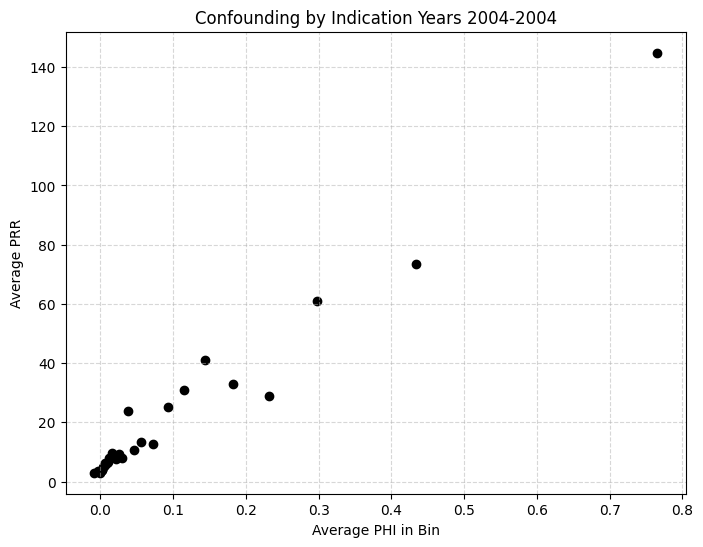

(8070, 5)

In [113]:
# Load DataFrames
start_year = 2004
end_year = 2004
ind_rea_df, ind_drug_df, drug_rea_df = load_csv_files(start_year, end_year)

data = confounder_drug_reaction_correlation(
    ind_rea_df,  # DataFrame for confounder-reaction links
    ind_drug_df, # DataFrame for confounder-drug links
    drug_rea_df, # DataFrame for drug-reaction links
    conf_rea_threshold=10,  # Identify strong indication-reaction links
    min_threshold_for_drug=40,  # Threshold for PRR in drugs
    num_bins=30, # Number of bins to group data in plot
    type='mean', # calculate proportion above threshold or mean
    conf_rea_col = 'PRR', # statistic to use for confounder-reaction relationship
    conf_drug_col = 'PHI', # statistic to use for confounder-drug relationship
    drug_rea_col = 'PRR', # statistic to use for drug-reaction relationship
    conf_name='Indication', # name of confounder
    title = f'Confounding by Indication Years {start_year}-{end_year}',
)

data.shape

In [117]:
data.sort_values(by='PRR_drug_rea', ascending=False).head(20)

,indication,reaction,drug,PHI_ind_drug,PRR_drug_rea
2418,CONTRACEPTION,MEDICAL DEVICE DISCOMFORT,ETONOGESTREL AND ETHINYL ESTRADIOL,0.778266,6992.496357
3288,ECZEMA,APPLICATION SITE DRYNESS,PIMECROLIMUS,0.714252,4527.821615
2428,CONTRACEPTION,WITHDRAWAL BLEEDING IRREGULAR,ETONOGESTREL AND ETHINYL ESTRADIOL,0.778266,3750.165644
40,ABORTION INDUCED,ABORTION INCOMPLETE,MISOPROSTOL,0.299006,3388.999337
3231,DRUG USE FOR UNKNOWN INDICATION,LIVE BIRTH,ISOTRETINOIN,0.149459,3202.692555
3896,HODGKIN'S DISEASE,AZOOSPERMIA,VINBLASTINE SULFATE,0.511226,2706.760563
593,ANTIVIRAL PROPHYLAXIS,RESPIRATORY SYNCYTIAL VIRUS INFECTION,PALIVIZUMAB,0.702043,2482.011743
3892,HODGKIN'S DISEASE,AZOOSPERMIA,DOXORUBICIN,0.039969,2432.563291
3910,HORMONE REPLACEMENT THERAPY,BREAST OPERATION,CONJUGATED ESTROGENS AND MEDROXYPROGESTERONE A...,0.609629,2317.829744
3888,HODGKIN'S DISEASE,AZOOSPERMIA,"BLEOMYCIN,BLEOMYCIN SULFATE",0.366408,1574.853996
